<h1>Interacting Particles</h1>

In this notebook we investigate a system of particles in a lattice with spins +1 or -1, interacting with others particles and a magnetic field. $H$ is the magnetic field strength and $J$ is the interaction energy.

The Hamiltonian is:

$$
E = - H \sum_i s_i + J\sum_{\langle i,j \rangle} \frac{s_i s_j}{d(i, j)}
$$

where the summation over $\langle i,j \rangle$ is over every pair of atoms in the lattice and $d(i, j)$ is the euclidean distance between particles at index $i$ and $j$.

In [303]:
import numpy as np
import matplotlib.pyplot as plt

<h2>Generating States</h2>

'Moves' are used in the Metropolis Monte-Carlo algorithm to change state. A move can either be the flipping of a single spin or flipping all spins, with probability $\frac{1}{N^2+1}$.

In [273]:
#N is the number of states on each axis. Returns an N*N array
def genState(N):
    return np.random.choice((-1.0, 1.0), (N, N))

def getMove(N):
    return np.random.randint(0, N*N)

def makeMove(spins, move):
    N = spins.shape[0]
    i, j = int( np.floor( move / N ) ), move%N

    if move == N*N:
        return -spins
    else:
        newSpins = np.copy(spins)
        newSpins[i, j] *= -1
        return newSpins

<h2>Calculating Energies</h2>
The energy calculation here is a primitive $O(N^4)$ calculation, so this method is only feasable for small lattices.

In [275]:
def dist(x, y, i, j):
    return np.sqrt((x - i)**2 + (y-j)**2)

def hamiltonian( spins, H, J ) :
    N = spins.shape[0]
    energy = 0
    
    #Loops through every particle
    for i in range(N):
        for j in range(N):
            
            #Magnetic field strength
            energy -= H * spins[i, j]
            
            #Interactions - considers only right and down to avoid double counting
            for x in range(i+1, N):
                for y in range(j+1, N):
                    energy += J * spins[i, j] * spins[x, y] / dist(x, y, i, j)
                    
    return energy

<h2>Metropolis monte-carlo</h2>

0 of 50100
10 of 50100
20 of 50100
30 of 50100
40 of 50100
50 of 50100
60 of 50100
70 of 50100
80 of 50100
90 of 50100
100 of 50100
110 of 50100
120 of 50100
130 of 50100
140 of 50100
150 of 50100
160 of 50100
170 of 50100
180 of 50100
190 of 50100
200 of 50100
210 of 50100
220 of 50100
230 of 50100
240 of 50100
250 of 50100
260 of 50100
270 of 50100
280 of 50100
290 of 50100
300 of 50100
310 of 50100
320 of 50100
330 of 50100
340 of 50100
350 of 50100
360 of 50100
370 of 50100
380 of 50100
390 of 50100
400 of 50100
410 of 50100
420 of 50100
430 of 50100
440 of 50100
450 of 50100
460 of 50100
470 of 50100
480 of 50100
490 of 50100
500 of 50100
510 of 50100
520 of 50100
530 of 50100
540 of 50100
550 of 50100
560 of 50100
570 of 50100
580 of 50100
590 of 50100
600 of 50100
610 of 50100
620 of 50100
630 of 50100
640 of 50100
650 of 50100
660 of 50100
670 of 50100
680 of 50100
690 of 50100
700 of 50100
710 of 50100
720 of 50100
730 of 50100
740 of 50100
750 of 50100
760 of 50100
770 of 501

Text(0, 0.5, 'Average magnetisation per spin / arbitrary units')

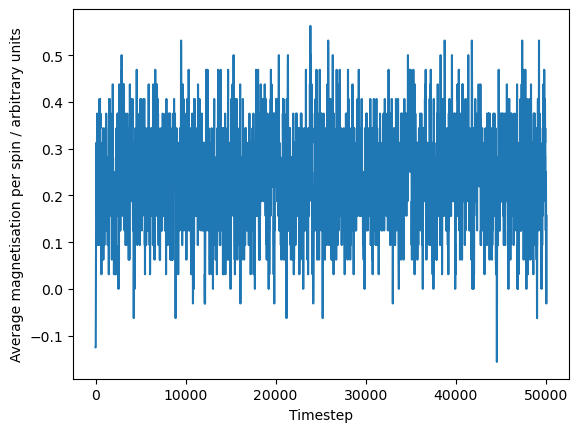

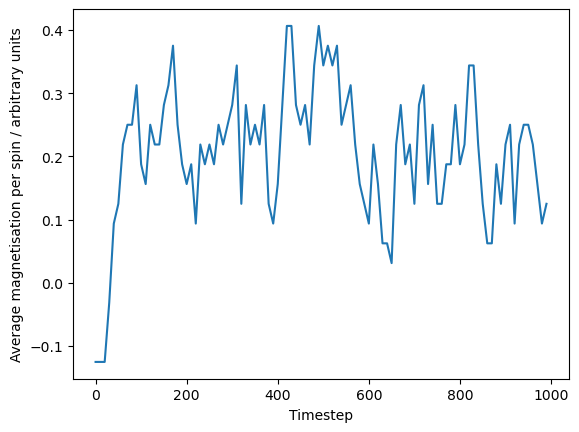

In [277]:
iterations = 50000 + 100 #100 for equilibriation
stride = 10

N = 8
H = 4
J = 8
temp = 10

spins = genState(N)
energy = hamiltonian(spins, H, J)

#Average magnetisation per spin
avgMagnetisations = np.zeros(iterations//stride)
times = np.zeros(iterations//stride)

for i in range(iterations):
    move = np.random.randint(0, N*N+1)
    newEnergy = hamiltonian(makeMove(spins, move), H, 1)

    if newEnergy <= energy:
        spins = makeMove(spins, move)
        energy = newEnergy
    else:
        acceptProb = np.exp(-(1/temp) * newEnergy) / np.exp(-(1/temp) * energy)
        if np.random.rand() < acceptProb:
            spins = makeMove(spins, move)
            energy = newEnergy

    #Records magnetisation per spin
    if i%stride == 0:
        print(f'{i} of {iterations}')
        avgMagnetisations[i//stride] = np.mean(spins)
        times[i//stride] = i


plt.plot(times, avgMagnetisations)
plt.xlabel("Timestep")
plt.ylabel("Average magnetisation per spin / arbitrary units")

plt.figure()
plt.plot(times[:1000//stride], avgMagnetisations[:1000//stride])
plt.xlabel("Timestep")
plt.ylabel("Average magnetisation per spin / arbitrary units")

In [278]:
#Removes first 100 elements to account for equilibriation time
avgMagnetisations = avgMagnetisations[200//stride:]

<h2>Probability Density</h2>
The probability density of a spin can be estimated from the magnetisations by computing a histogram. This histogram can be plotted as a line, after normalisation, in order to plot the estimated probabilities.

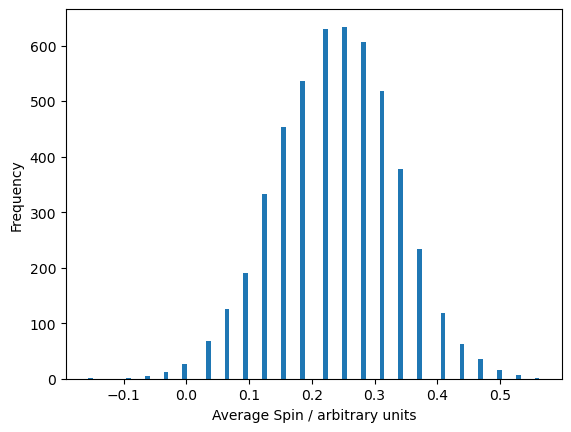

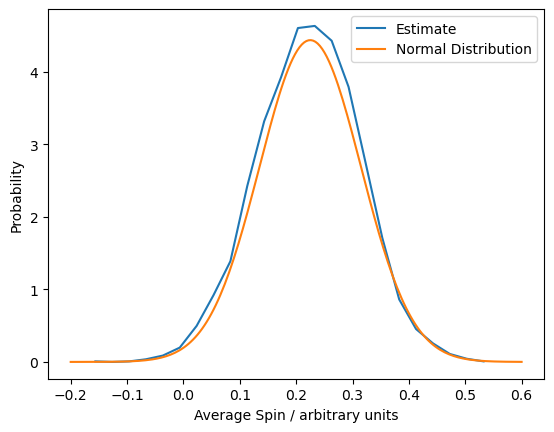

In [323]:
nBins = 24
densities = np.histogram(avgMagnetisations, nBins)[0]
avgSpins = np.histogram(avgMagnetisations, nBins)[1][:-1]

#Normalisation - Probability densities add to 1
binWidth = (avgSpins[-1]-avgSpins[1]) / nBins
area = np.sum(densities) * binWidth
densities = densities / area
np.sum(densities)


#Plotting Histogram
plt.hist(avgMagnetisations, nBins * 4)
plt.xlabel("Average Spin / arbitrary units")
plt.ylabel("Frequency")

#Plotting Probability
plt.figure()
plt.plot(avgSpins, densities, label="Estimate")
plt.xlabel("Average Spin / arbitrary units")
plt.ylabel("Probability")

dev = 0.09
mean = 0.225
x = np.linspace(-0.2, 0.6, 200)
y = np.exp(-((x-mean)/dev)**2 / 2) / (dev * np.sqrt(2 * np.pi))

plt.plot(x, y, label = "Normal Distribution")

plt.legend()

In [297]:
len(avgMagnetisations)

4990

In [313]:
avgSpins

array([-0.15625   , -0.12630208, -0.09635417, -0.06640625, -0.03645833,
       -0.00651042,  0.0234375 ,  0.05338542,  0.08333333,  0.11328125,
        0.14322917,  0.17317708,  0.203125  ,  0.23307292,  0.26302083,
        0.29296875,  0.32291667,  0.35286458,  0.3828125 ,  0.41276042,
        0.44270833,  0.47265625,  0.50260417,  0.53255208])